# Decision Tree Classifier Implementation

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.datasets  import load_iris

In [4]:
iris=load_iris()

In [5]:
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [6]:
print(iris['target'])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [7]:
##independent features
X=pd.DataFrame(iris['data'],columns=['sepal length','sepal width','petal length','petal width'])

In [8]:
X.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
##dependent features
y=iris['target']

In [10]:
##train test plot
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

In [11]:
## Apply Decision tree Classifier

from sklearn.tree import DecisionTreeClassifier
treeclassifier =  DecisionTreeClassifier()
treeclassifier.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.3076923076923077, 0.9285714285714286, 'x[3] <= 0.8\ngini = 0.665\nsamples = 120\nvalue = [40, 37, 43]'),
 Text(0.23076923076923078, 0.7857142857142857, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.2692307692307693, 0.8571428571428572, 'True  '),
 Text(0.38461538461538464, 0.7857142857142857, 'x[2] <= 4.75\ngini = 0.497\nsamples = 80\nvalue = [0, 37, 43]'),
 Text(0.34615384615384615, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'x[3] <= 1.65\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6153846153846154, 0.6428571428571429, 'x[3] <= 1.75\ngini = 0.159\nsamples = 46\nvalue = [0, 4, 42]'),
 Text(0.38461538461538464, 0.5, 'x[1] <= 2.65\ngini = 0.49\nsamples = 7\nvalue = [0, 3, 4]'),
 Text(0.3076923076923077, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [0, 

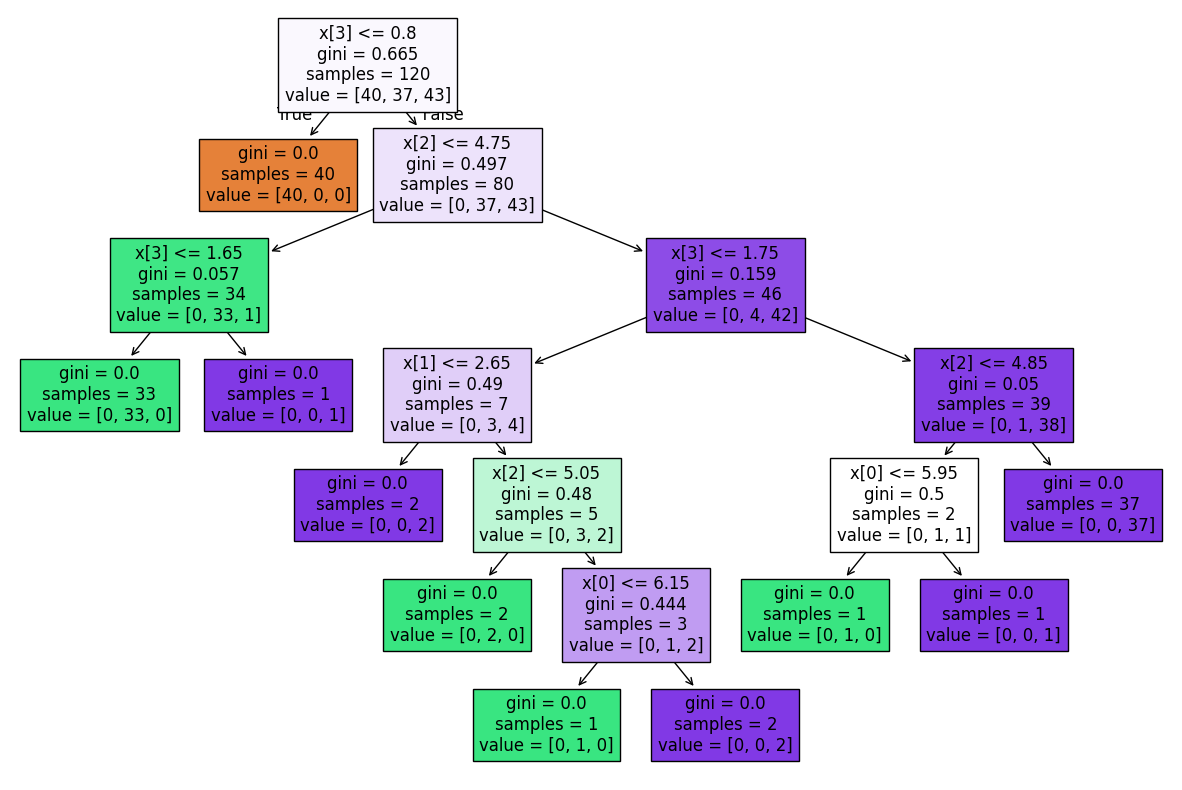

In [12]:
##Visualize the Decision Tree
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(treeclassifier,filled=True)

In [14]:
y_pred = treeclassifier.predict(X_test)

In [15]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [16]:

accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.9666666666666667


In [17]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[10  0  0]
 [ 0 12  1]
 [ 0  0  7]]


In [18]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.92      0.96        13
           2       0.88      1.00      0.93         7

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



# Post Pruning

### Post-Pruning

* The Decision Tree was first grown to its maximum depth, which may lead to **overfitting**.
* **Post-pruning** reduces overfitting by removing unnecessary branches after the full tree is constructed.
* In the image above, the tree is pruned to **depth = 2**.
* At this depth, one class clearly dominates the others, making further splits unnecessary.
* Additional splits only increase model complexity without significantly improving accuracy.
* The pruned tree is **simpler, less prone to overfitting, and generalizes better to unseen data**.


In [19]:
postpruningtree = DecisionTreeClassifier(max_depth=2)
postpruningtree.fit(X_train,y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


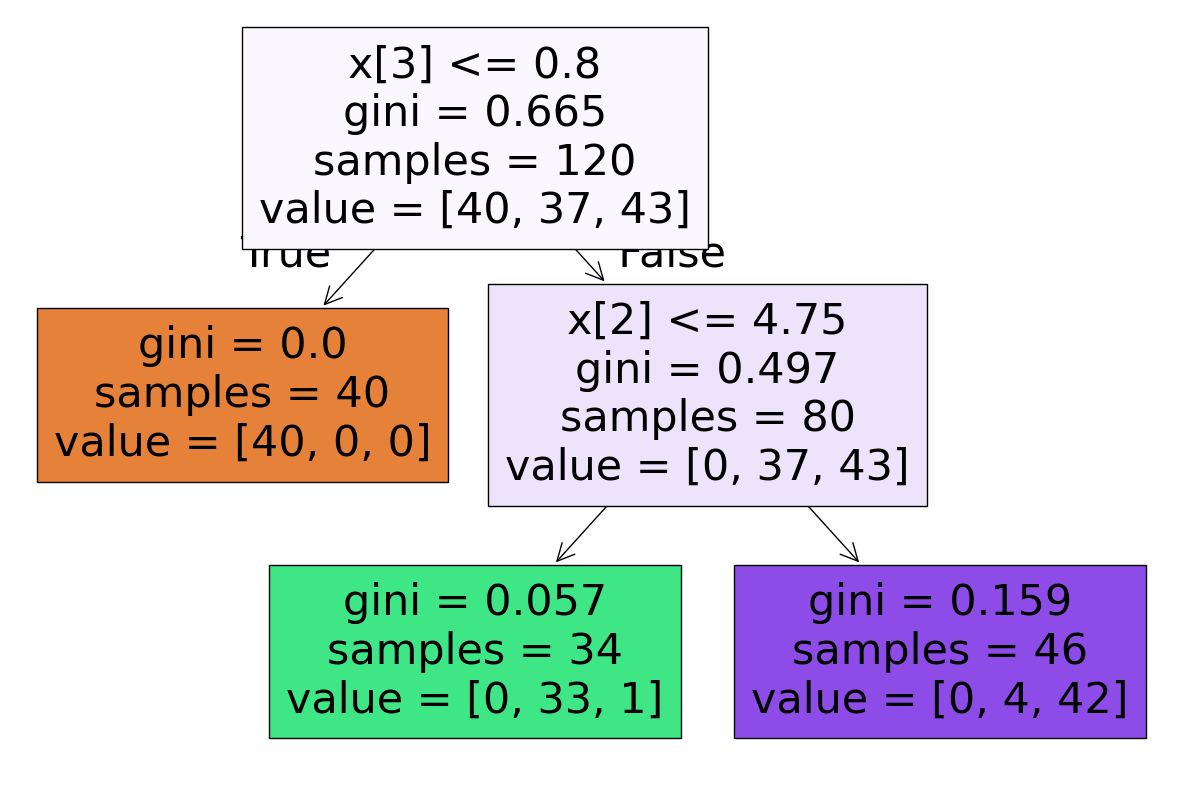

In [20]:
plt.figure(figsize=(15,10))
tree.plot_tree(postpruningtree,filled=True)
y_pred=postpruningtree.predict(X_test)

In [22]:
y_pred_post_pruning = postpruningtree.predict(X_test)


In [23]:
# calculating metrics for post pruning tree
accuracy=accuracy_score(y_test,y_pred_post_pruning)
print(accuracy)
cm=confusion_matrix(y_test,y_pred_post_pruning)
print(cm)
print(classification_report(y_test,y_pred_post_pruning))

0.9333333333333333
[[10  0  0]
 [ 0 11  2]
 [ 0  0  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.85      0.92        13
           2       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.95      0.93        30
weighted avg       0.95      0.93      0.93        30



## Decision Tree Classifier: Pre-Pruning and Hyperparameter Tuning

* **Pre-pruning** prevents the Decision Tree from growing too deep, reducing the risk of overfitting.
* It stops further splitting based on predefined conditions, resulting in a simpler and more generalized model.
* **Hyperparameter tuning** is the process of finding the best values for the model's parameters to improve performance.
* Common pre-pruning hyperparameters include:

  * `max_depth` – Maximum depth of the tree.
  * `min_samples_split` – Minimum samples required to split a node.
  * `min_samples_leaf` – Minimum samples required in a leaf node.
  * `max_leaf_nodes` – Maximum number of leaf nodes.
  * `criterion` – Splitting criterion (`gini` or `entropy`).
* The best hyperparameter values can be selected using techniques such as **GridSearchCV** or **RandomizedSearchCV** with cross-validation.
* Proper hyperparameter tuning helps improve model accuracy while preventing overfitting.


In [24]:
param={
    'criterion':['gini','entropy', 'log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5],
    'max_features':['auto','sqrt','log2']
}

In [25]:
param

{'criterion': ['gini', 'entropy', 'log_loss'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 2, 3, 4, 5],
 'max_features': ['auto', 'sqrt', 'log2']}

In [27]:
from sklearn.model_selection import GridSearchCV
treemodel = DecisionTreeClassifier

In [28]:
grid=GridSearchCV(treeclassifier,param_grid=param,cv=5,scoring='accuracy')

In [29]:
grid.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [30]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 5,
 'max_features': 'sqrt',
 'splitter': 'random'}

In [31]:
grid.best_score_

np.float64(0.9416666666666667)

In [32]:
y_pred=grid.predict(X_test)

In [33]:
y_pred

array([1, 2, 0, 2, 0, 1, 2, 1, 0, 1, 2, 2, 1, 0, 0, 2, 2, 0, 0, 0, 2, 2,
       2, 0, 2, 0, 0, 1, 2, 2])

In [34]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[10  0  0]
 [ 1  6  6]
 [ 0  0  7]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.46      0.63        13
           2       0.54      1.00      0.70         7

    accuracy                           0.77        30
   macro avg       0.82      0.82      0.76        30
weighted avg       0.86      0.77      0.75        30



In [35]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.7666666666666667
